In [1]:
# ============================================================
# CELL 1: Install dependencies
# ============================================================
!pip install -q tensorflow opencv-python-headless moviepy scikit-learn matplotlib seaborn

import os, cv2, math, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Dropout, Flatten,
                                     Dense, LSTM, TimeDistributed, BatchNormalization)
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
warnings.filterwarnings('ignore')
np.random.seed(42); tf.random.set_seed(42)
print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
# ============================================================
# CELL 2 (FIXED): Download UCF50 via Kaggle API
# Step 1: Upload your kaggle.json first:
#   Kaggle → Account → API → Create New Token → upload here
# ============================================================
from google.colab import files
files.upload()   # upload kaggle.json when prompted

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download UCF50 from Kaggle
!kaggle datasets download -d vineethakkinapalli/ucf50-action-recognition-dataset
!unzip -q ucf50-action-recognition-dataset.zip -d UCF50_raw

# # Find the actual UCF50 folder inside
# import os, shutil
# for root, dirs, files_ in os.walk('UCF50_raw'):
#     for d in dirs:
#         if d == 'UCF50':
#             shutil.copytree(os.path.join(root, d), 'UCF50')
#             break

# classes = os.listdir('UCF50')
# print(f"Total classes: {len(classes)}")
# print("Sample classes:", classes[:8])

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/vineethakkinapalli/ucf50-action-recognition-dataset
License(s): unknown
100% 3.04G/3.04G [03:08<00:00, 17.3MB/s]



FileExistsError: [Errno 17] File exists: 'UCF50'

In [7]:
# ============================================================
# CELL 2b (FIX): UCF50 folder already exists — just verify it
# ============================================================
import os

# If UCF50 exists but is empty, find it inside UCF50_raw
if not os.path.exists('UCF50') or len(os.listdir('UCF50')) == 0:
    import shutil
    for root, dirs, files_ in os.walk('UCF50_raw'):
        for d in dirs:
            if d == 'UCF50':
                shutil.copytree(os.path.join(root, d), 'UCF50', dirs_exist_ok=True)
                break

classes = [d for d in os.listdir('UCF50')
           if os.path.isdir(os.path.join('UCF50', d))]
print(f"✅ Total classes : {len(classes)}")
print(f"Sample classes  : {classes[:8]}")

# Count total videos
total = sum(len(os.listdir(f'UCF50/{c}')) for c in classes)
print(f"Total videos    : {total}")

✅ Total classes : 50
Sample classes  : ['JavelinThrow', 'Swing', 'PlayingPiano', 'HorseRiding', 'HorseRace', 'Biking', 'Nunchucks', 'JugglingBalls']
Total videos    : 6681


In [8]:
# ============================================================
# CELL 3: Global config
# ============================================================
IMAGE_HEIGHT    = 64
IMAGE_WIDTH     = 64
SEQUENCE_LENGTH = 20          # frames per video clip
DATASET_DIR     = "UCF50"
SEED            = 42

# Use only 4 classes for quick training; expand as needed
CLASSES_LIST = ["WalkingWithDog", "TaiChi", "Swing", "HorseRace"]

print(f"Image size   : {IMAGE_HEIGHT}x{IMAGE_WIDTH}")
print(f"Sequence len : {SEQUENCE_LENGTH} frames/clip")
print(f"Classes      : {CLASSES_LIST}")

Image size   : 64x64
Sequence len : 20 frames/clip
Classes      : ['WalkingWithDog', 'TaiChi', 'Swing', 'HorseRace']


In [9]:
# ============================================================
# CELL 4: TASK 1 — Extract uniformly-spaced frames from videos
# ============================================================
def extract_frames(video_path, sequence_length=SEQUENCE_LENGTH):
    """Extract `sequence_length` evenly-spaced frames from a video."""
    frames = []
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    skip  = max(1, total // sequence_length)

    for i in range(sequence_length):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * skip)
        ok, frame = cap.read()
        if not ok:
            break
        frame = cv2.resize(frame, (IMAGE_HEIGHT, IMAGE_WIDTH))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame / 255.0)            # normalize [0,1]

    cap.release()
    # Pad with zeros if not enough frames
    while len(frames) < sequence_length:
        frames.append(np.zeros((IMAGE_HEIGHT, IMAGE_WIDTH, 3)))
    return np.array(frames[:sequence_length])


def build_dataset(dataset_dir, classes, sequence_length=SEQUENCE_LENGTH):
    """Build features and labels arrays."""
    features, labels = [], []
    for label_idx, cls in enumerate(classes):
        cls_path = os.path.join(dataset_dir, cls)
        video_files = os.listdir(cls_path)
        print(f"  [{cls}] — {len(video_files)} videos")
        for vf in video_files:
            vpath = os.path.join(cls_path, vf)
            seq = extract_frames(vpath, sequence_length)
            if seq.shape == (sequence_length, IMAGE_HEIGHT, IMAGE_WIDTH, 3):
                features.append(seq)
                labels.append(label_idx)
    return np.array(features, dtype=np.float32), np.array(labels)


print("Extracting frames …")
features, labels = build_dataset(DATASET_DIR, CLASSES_LIST)
one_hot_labels   = to_categorical(labels, num_classes=len(CLASSES_LIST))

print(f"\nFeatures shape : {features.shape}")  # (N, 20, 64, 64, 3)
print(f"Labels shape   : {one_hot_labels.shape}")

Extracting frames …
  [WalkingWithDog] — 123 videos
  [TaiChi] — 100 videos
  [Swing] — 137 videos
  [HorseRace] — 127 videos

Features shape : (487, 20, 64, 64, 3)
Labels shape   : (487, 4)


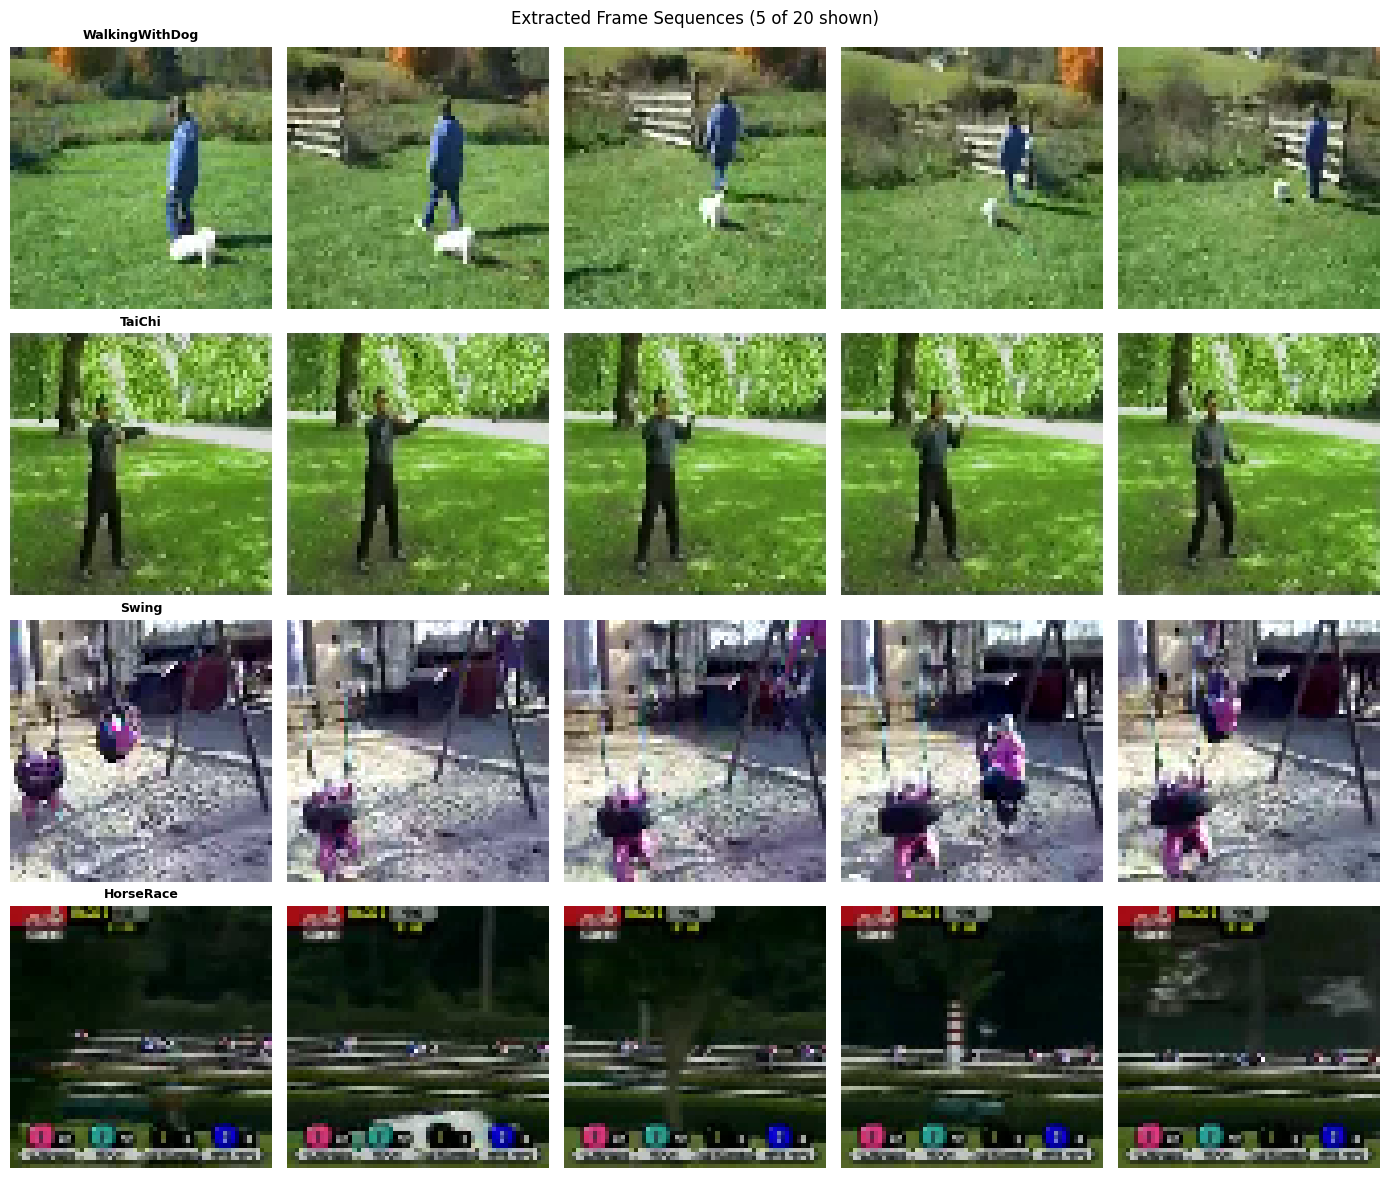

In [10]:
# ============================================================
# CELL 5: Visualize one sample sequence per class
# ============================================================
fig, axes = plt.subplots(len(CLASSES_LIST), 5, figsize=(14, 3*len(CLASSES_LIST)))
for row, cls in enumerate(CLASSES_LIST):
    idx = np.where(labels == row)[0][0]
    for col, frame_no in enumerate([0, 4, 9, 14, 19]):
        axes[row, col].imshow(features[idx][frame_no])
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls, fontsize=9, fontweight='bold')
plt.suptitle("Extracted Frame Sequences (5 of 20 shown)", fontsize=12)
plt.tight_layout(); plt.show()

In [11]:
# ============================================================
# CELL 6: Split data
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    features, one_hot_labels,
    test_size=0.25, shuffle=True, random_state=SEED
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (365, 20, 64, 64, 3)  |  Test: (122, 20, 64, 64, 3)


In [12]:
# ============================================================
# CELL 7: TASK 2 — CNN-LSTM model
#   TimeDistributed(CNN)  →  extracts spatial features per frame
#   LSTM                  →  models temporal dependencies
# ============================================================
def build_cnn_lstm(seq_len, h, w, n_classes):
    model = Sequential([
        # --- Spatial Feature Extractor (CNN applied to each frame) ---
        TimeDistributed(Conv2D(32, (3,3), activation='relu', padding='same'),
                        input_shape=(seq_len, h, w, 3)),
        TimeDistributed(BatchNormalization()),
        TimeDistributed(MaxPooling2D((2,2))),
        TimeDistributed(Dropout(0.25)),

        TimeDistributed(Conv2D(64, (3,3), activation='relu', padding='same')),
        TimeDistributed(BatchNormalization()),
        TimeDistributed(MaxPooling2D((2,2))),
        TimeDistributed(Dropout(0.25)),

        TimeDistributed(Conv2D(128, (3,3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2,2))),
        TimeDistributed(Flatten()),         # (batch, seq_len, feature_vec)

        # --- Temporal Modelling (LSTM) ---
        LSTM(128, return_sequences=True),
        Dropout(0.3),
        LSTM(64),
        Dropout(0.3),

        # --- Classifier ---
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_cnn_lstm(SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, len(CLASSES_LIST))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 20, 64, 64, 32) │           896 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 20, 64, 64, 32) │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 20, 32, 32, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 20, 32, 32, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 20, 32, 32, 64) │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 20, 32, 32, 64) │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 20, 16, 16, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 20, 16, 16, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 20, 16, 16,     │        73,856 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 20, 8, 8, 128)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ (None, 20, 8192)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 20, 128)        │     4,260,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,412,228 (16.83 MB)

 Trainable params: 4,412,036 (16.83 MB)

 Non-trainable params: 192 (768.00 B)

In [13]:
# ============================================================
# CELL 8: TASK 2 — Train CNN-LSTM
# ============================================================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 32s 237ms/step - accuracy: 0.2581 - loss: 1.4126 - val_accuracy: 0.3273 - val_loss: 1.3820 - learning_rate: 0.0010
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 148ms/step - accuracy: 0.2355 - loss: 1.4015 - val_accuracy: 0.3273 - val_loss: 1.3726 - learning_rate: 0.0010
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 155ms/step - accuracy: 0.2774 - loss: 1.4041 - val_accuracy: 0.3273 - val_loss: 1.3729 - learning_rate: 0.0010
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 148ms/step - accuracy: 0.2903 - loss: 1.3770 - val_accuracy: 0.5091 - val_loss: 1.3413 - learning_rate: 0.0010
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 158ms/step - accuracy: 0.3774 - loss: 1.3417 - val_accuracy: 0.4364 - val_loss: 1.3324 - learning_rate: 0.0010
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 147ms/step - accuracy: 0.4161 - loss: 1.2726 - val_accuracy: 0.4182 - val_loss: 1.3841 - learning_rate: 0.0010
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 154ms/step - accuracy: 0.4258 - loss: 1.2600 -


  Test Loss     : 0.6880
  Test Accuracy : 72.13%

                precision    recall  f1-score   support

WalkingWithDog       0.57      0.34      0.43        35
        TaiChi       0.71      0.77      0.74        22
         Swing       0.62      0.80      0.70        25
     HorseRace       0.87      0.97      0.92        40

      accuracy                           0.72       122
     macro avg       0.69      0.72      0.70       122
  weighted avg       0.70      0.72      0.70       122



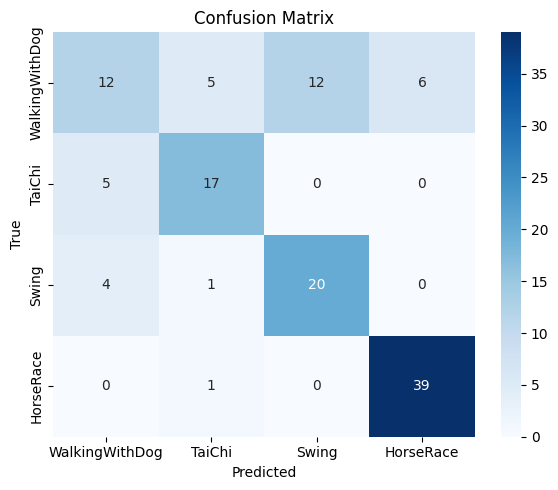

In [14]:
# ============================================================
# CELL 9: TASK 3 — Evaluate on test set
# ============================================================
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n{'='*40}")
print(f"  Test Loss     : {loss:.4f}")
print(f"  Test Accuracy : {acc*100:.2f}%")
print(f"{'='*40}\n")

# Predictions
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test,      axis=1)

# Classification report
print(classification_report(y_true, y_pred, target_names=CLASSES_LIST))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES_LIST, yticklabels=CLASSES_LIST)
plt.title("Confusion Matrix"); plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()

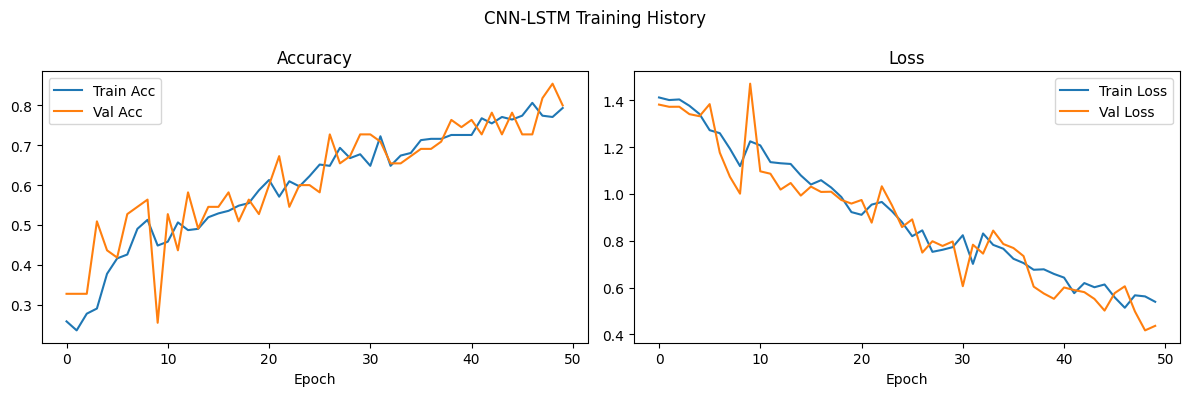

In [15]:
# ============================================================
# CELL 10: Training & validation curves
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'],     label='Train Acc')
ax1.plot(history.history['val_accuracy'], label='Val Acc')
ax1.set_title('Accuracy'); ax1.legend(); ax1.set_xlabel('Epoch')

ax2.plot(history.history['loss'],     label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Loss'); ax2.legend(); ax2.set_xlabel('Epoch')

plt.suptitle("CNN-LSTM Training History"); plt.tight_layout(); plt.show()


Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 1.


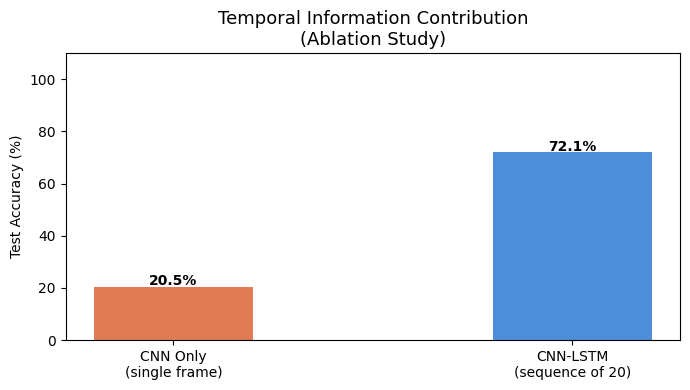


CNN Only (no temporal)  : 20.49%
CNN-LSTM (with temporal): 72.13%
Accuracy gain from LSTM : +51.64%


In [16]:
# ============================================================
# CELL 11: TASK 4 — Ablation: CNN-only (no temporal context)
# ============================================================
def build_cnn_only(h, w, n_classes):
    """Baseline: classify from a single middle frame (no LSTM)."""
    model = Sequential([
        Conv2D(32,  (3,3), activation='relu', padding='same',
               input_shape=(h, w, 3)),
        MaxPooling2D((2,2)), Dropout(0.25),
        Conv2D(64,  (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)), Dropout(0.25),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(256, activation='relu'), Dropout(0.4),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Use only the middle frame
mid = SEQUENCE_LENGTH // 2
X_train_single = X_train[:, mid, :, :, :]
X_test_single  = X_test[:,  mid, :, :, :]

cnn_model = build_cnn_only(IMAGE_HEIGHT, IMAGE_WIDTH, len(CLASSES_LIST))
cnn_model.fit(X_train_single, y_train,
              epochs=30, batch_size=16,
              validation_split=0.15,
              callbacks=callbacks, verbose=0)

_, cnn_acc     = cnn_model.evaluate(X_test_single, y_test, verbose=0)
_, cnn_lstm_acc = model.evaluate(X_test, y_test, verbose=0)

# Bar chart comparison
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['CNN Only\n(single frame)', 'CNN-LSTM\n(sequence of 20)'],
              [cnn_acc*100, cnn_lstm_acc*100],
              color=['#e07b54', '#4c8eda'], width=0.4)
for bar, v in zip(bars, [cnn_acc, cnn_lstm_acc]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{v*100:.1f}%', ha='center', fontweight='bold')
ax.set_ylim(0, 110)
ax.set_title("Temporal Information Contribution\n(Ablation Study)", fontsize=13)
ax.set_ylabel("Test Accuracy (%)")
plt.tight_layout(); plt.show()

print(f"\nCNN Only (no temporal)  : {cnn_acc*100:.2f}%")
print(f"CNN-LSTM (with temporal): {cnn_lstm_acc*100:.2f}%")
print(f"Accuracy gain from LSTM : +{(cnn_lstm_acc-cnn_acc)*100:.2f}%")